In [35]:
import numpy as np
import scipy.stats
import scipy.special
import matplotlib.pyplot as plt
import random
import yaml
SEED = 12345
random.seed(SEED)
np.random.seed(SEED)

# 1 Parameter inference for the linear Gaussian model
Consider the following scalar linear Gaussian model

$$X_n = \rho X_{n-1} + \tau V_n $$

$$Y_n = X_n + \sigma W_n$$

where $W_n, V_n \overset{i.i.d}{\sim} N(0, 1), X_0 ∼ N(0, 1)$. We first run the model to synthesise a data set $y_{0:T}$ for $T = 100, \rho = 0.8, \tau = 1, \sigma = 0.5$. We also store the real state trajectory, $x_{0:T}$. Let $\theta = (\rho, \tau)$ and assume $\sigma$ is known. Let also $\rho \in [-1,1]$ and
$\tau \in (0, 2]$. We wish to perform Bayesian inference using MCMC with the priors $\rho \sim U[-1,1]$ and $\tau \sim N_{(0,2]}(1,1)$, where the latter denotes a truncated normal distribution in $(0, 2]$.

In [36]:
# Import trajectory 
results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/lgssm/data/"
experiment_ID = 1
trajectory_path = results_path + f"trajectory{experiment_ID}.npz"
trajectory_config_path = results_path + f"trajectory{experiment_ID}.yaml"

trajectory = np.load(trajectory_path)
T = 100 # Length of time series to use
x = trajectory["x"][:T+1]
z = trajectory["z"][:T+1]

with open(trajectory_config_path, "r") as f:
    trajectory_config = yaml.safe_load(f)
rho_true = trajectory_config["rho_true"]
sigma_true = trajectory_config["sigma_true"]
tau_true = trajectory_config["tau_true"]
trajectory_config

{'length': 5000, 'rho_true': 0.8, 'sigma_true': 0.5, 'tau_true': 1.0}

In [ ]:
def log_likelihood_given_z(x, z, sigma):
    """
    p(x_{0:T} | z_{0:T}, sigma) = prod_k N(x_k; z_k, sigma^2)
    """
    return np.sum(scipy.stats.norm.logpdf(x, loc=z, scale=sigma))


def log_prior_z(z, rho, tau):
    """
    log p(z_{0:T} | rho, tau)
    = log N(z_0; 0, 1) + sum_{k=1}^T log N(z_k; rho*z_{k-1}, tau^2)
    """
    # Z0 ~ N(0,1)
    lp = scipy.stats.norm.logpdf(z[0], loc=0.0, scale=1.0)
    # Zn ~ N(rho * Z_{n-1}, tau)
    lp += np.sum(scipy.stats.norm.logpdf(z[1:], loc=rho * z[:-1], scale=tau))
    return lp


def log_prior_params(rho, tau, rho_lower, rho_upper,
                     tau_loc, tau_scale, tau_lower, tau_upper):
    if not (rho_lower < rho < rho_upper):
        return -np.inf
    if not (tau_lower < tau < tau_upper):
        return -np.inf
    log_p_rho = -np.log(rho_upper - rho_lower)
    log_p_tau = -0.5 * ((tau - tau_loc) / tau_scale) ** 2
    return log_p_rho + log_p_tau


def kalman_filter(x, rho, tau, sigma):
    """
    Forward Kalman filter.
    Returns filtered means and variances, and predicted means and variances.
    """
    T = len(x) - 1
    sigma2 = sigma ** 2
    mu_filt = np.zeros(T + 1)
    s2_filt = np.zeros(T + 1)
    mu_pred = np.zeros(T + 1)
    s2_pred = np.zeros(T + 1)

    for k in range(T + 1):
        if k == 0:
            mp, sp = 0.0, 1.0
        else:
            mp = rho * mu_filt[k-1]
            sp = rho ** 2 * s2_filt[k-1] + tau ** 2
        mu_pred[k] = mp
        s2_pred[k] = sp
        s2_innov = sp + sigma2
        K = sp / s2_innov
        mu_filt[k] = mp + K * (x[k] - mp)
        s2_filt[k] = sp - K * sp

    return mu_filt, s2_filt, mu_pred, s2_pred


def ffbs_sample(x, rho, tau, sigma):
    """
    Forward-filter backward-sample: draws one exact sample from
    p(z_{0:T} | x_{0:T}, rho, tau, sigma).
    """
    T = len(x) - 1
    mu_filt, s2_filt, mu_pred, s2_pred = kalman_filter(x, rho, tau, sigma)

    z = np.zeros(T + 1)

    # Sample z_T from p(z_T | x_{0:T})
    z[T] = np.random.normal(mu_filt[T], np.sqrt(s2_filt[T]))

    # Backward pass
    for k in range(T - 1, -1, -1):
        # p(z_k | z_{k+1}, x_{0:k}) is Gaussian
        # Mean and variance from standard Kalman smoother equations
        G = s2_filt[k] * rho / s2_pred[k+1]        # smoother gain
        mu_smooth = mu_filt[k] + G * (z[k+1] - mu_pred[k+1])
        s2_smooth = s2_filt[k] - G ** 2 * s2_pred[k+1]
        z[k] = np.random.normal(mu_smooth, np.sqrt(s2_smooth))

    return z


def metropolis_hastings_with_z(rho_0, tau_0, x, sigma, proposal_sigmas,
                                num_iterations,
                                rho_lower, rho_upper,
                                tau_loc, tau_scale, tau_lower, tau_upper):
    """
    Gibbs-within-MH sampler for p(rho, tau, z_{0:T} | x_{0:T}).

    At each iteration:
      1. Sample z_{0:T} | rho, tau, x_{0:T} exactly via FFBS
      2. Propose (rho*, tau*) and accept/reject via MH
         using log p(z_{0:T} | rho, tau) + log p(rho, tau) as the target
    """
    T = len(x) - 1
    proposal_sigmas = np.array(proposal_sigmas)

    # Storage
    rho_samples = np.zeros(num_iterations)
    tau_samples = np.zeros(num_iterations)
    z_samples = np.zeros((num_iterations, T + 1))

    # Initialise
    rho_prev = rho_0
    tau_prev = tau_0
    z_prev = ffbs_sample(x, rho_prev, tau_prev, sigma)

    rejections = 0

    for i in range(num_iterations):
        if i % (num_iterations // 10) == 0:
            print(f"{100 * i / num_iterations:.0f}% done")

        # Step 1: Sample z_{0:T} | rho, tau, x exactly via FFBS
        z_prev = ffbs_sample(x, rho_prev, tau_prev, sigma)

        # Step 2: MH update for (rho, tau) given z_{0:T}
        # Target: log p(z_{0:T} | rho, tau) + log p(rho, tau)
        log_target_prev = (log_prior_z(z_prev, rho_prev, tau_prev) +
                           log_prior_params(rho_prev, tau_prev,
                                            rho_lower, rho_upper,
                                            tau_loc, tau_scale,
                                            tau_lower, tau_upper))

        proposed = np.array([rho_prev, tau_prev]) + proposal_sigmas * np.random.randn(2)
        rho_prop, tau_prop = proposed[0], proposed[1]

        log_target_prop = (log_prior_z(z_prev, rho_prop, tau_prop) +
                           log_prior_params(rho_prop, tau_prop,
                                            rho_lower, rho_upper,
                                            tau_loc, tau_scale,
                                            tau_lower, tau_upper))

        if np.log(np.random.uniform()) < log_target_prop - log_target_prev:
            rho_prev = rho_prop
            tau_prev = tau_prop
        else:
            rejections += 1

        rho_samples[i] = rho_prev
        tau_samples[i] = tau_prev
        z_samples[i] = z_prev

    return rho_samples, tau_samples, z_samples, rejections / num_iterations


# Run
rho_0, tau_0 = 0.0, 0.5
proposal_sigmas = (0.05, 0.1)
num_iterations = 20000

# Prior hyperparameters
rho_lower, rho_upper = -1.0, 1.0
tau_loc, tau_scale, tau_lower, tau_upper = 1.0, 1.0, 0.0, 2.0

rho_samples, tau_samples, z_samples, rejection_rate = metropolis_hastings_with_z(
    rho_0, tau_0, x, sigma_true, proposal_sigmas, num_iterations,
    rho_lower, rho_upper,
    tau_loc, tau_scale, tau_lower, tau_upper
)

0% done
10% done
20% done
30% done
40% done
50% done
60% done
70% done
80% done
90% done


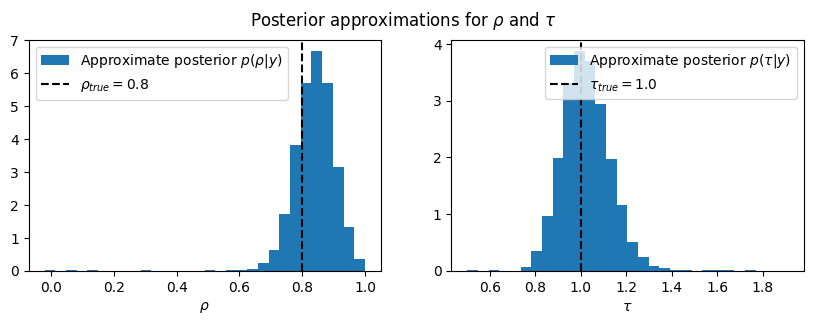

In [11]:
fig, ax = plt.subplots(figsize=(10,3), ncols=2)

bins=30
ax[0].hist(rho_samples, bins=bins, density=True, label=r"Approximate posterior $p(\rho | y)$")
ax[0].axvline(rho_true, linestyle="--", label=r"$\rho_{true} = $" + str(rho_true), color="k")
ax[0].set_xlabel(r"$\rho$")
ax[0].legend()

ax[1].hist(tau_samples, bins=bins, density=True, label=r"Approximate posterior $p(\tau | y)$")
ax[1].axvline(tau_true, linestyle="--", label=r"$\tau_{true} = $" + str(tau_true), color="k")
ax[1].set_xlabel(r"$\tau$")
ax[1].legend()

plt.suptitle(r"Posterior approximations for $\rho$ and $\tau$")

plt.show()

In [25]:
lq = np.quantile(z_samples, 0.025, axis=0)
uq = np.quantile(z_samples, 0.975, axis=0)
mean = np.mean(z_samples, axis=0)

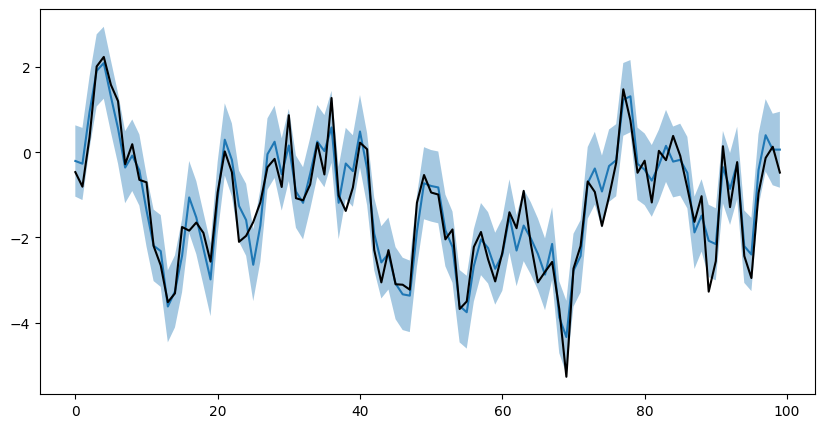

In [34]:
fig, ax = plt.subplots(figsize=(10,5))
time_range = range(T)
ax.fill_between(time_range, lq, uq, alpha=0.4)
ax.plot(mean)
ax.plot(z, color="k")